In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("swiggy_vs_zomato_3000.csv")

In [3]:
df

,restaurant_id,restaurant_name,city,locality,restaurant_type,cuisines,distance_from_city_center_km,opening_time,closing_time,days_operational,...,swiggy_market_share_pct,zomato_market_share_pct,platform_performance_better,amenities,amenities_count,has_own_website,has_own_app,food_license_verified,listing_date,days_listed
0,REST000001,Restaurant_1,Mumbai,Mumbai_Locality_9,Cafe,Italian,4.1,12:00,22:00,601,...,50.0,50.0,Swiggy Better,Live Music; Family Friendly; Vegan Options; Wi...,6,False,False,True,2023-03-04,1168
1,REST000002,Restaurant_2,Mumbai,Mumbai_Locality_13,Casual Dining,Mughlai,1.9,09:00,23:00,3501,...,49.0,51.0,Swiggy Better,Dessert Bar; Live Music; Rooftop,3,False,True,True,2016-09-11,3533
2,REST000003,Restaurant_3,Mumbai,Mumbai_Locality_12,Fine Dine,Mediterranean,2.9,08:00,23:00,1485,...,42.0,58.0,Swiggy Better,Dessert Bar; Parking; Rooftop; Dine-in,4,True,True,False,2017-04-05,3327
3,REST000004,Restaurant_4,Mumbai,Mumbai_Locality_19,Cloud Kitchen,Desserts,13.2,08:00,23:00,1318,...,66.0,34.0,Zomato Better,Live Music; Outdoor Seating; Alcohol; Family F...,5,True,True,True,2024-07-28,656
4,REST000005,Restaurant_5,Mumbai,Mumbai_Locality_13,Cafe,Mexican,6.0,11:00,23:00,1947,...,52.0,48.0,Swiggy Better,Rooftop; Outdoor Seating; Alcohol; Takeaway; D...,7,True,True,True,2022-02-04,1561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,REST002496,Restaurant_2496,Lucknow,Lucknow_Locality_10,Food Truck,Pan-Asian,6.7,12:00,22:00,1503,...,48.0,52.0,Swiggy Better,Smoking Area; Family Friendly; Outdoor Seating...,6,False,True,True,2023-12-07,890
2496,REST002497,Restaurant_2497,Lucknow,Lucknow_Locality_14,Fine Dine,Vietnamese; Mediterranean,2.6,09:00,22:00,576,...,54.0,46.0,Zomato Better,Dessert Bar; WiFi; Alcohol; Parking,4,True,True,False,2020-09-26,2057
2497,REST002498,Restaurant_2498,Lucknow,Lucknow_Locality_16,Food Truck,Multi-Cuisine,3.5,09:00,22:00,247,...,62.0,38.0,Zomato Better,Smoking Area; Family Friendly; Outdoor Seating...,6,False,False,True,2016-05-29,3638
2498,REST002499,Restaurant_2499,Lucknow,Lucknow_Locality_9,Cafe,Korean; Korean,10.4,09:00,22:00,3066,...,58.0,42.0,Swiggy Better,Live Music; WiFi; Dine-in; AC; Outdoor Seating...,7,False,True,False,2021-11-04,1653


In [4]:
df.isnull().sum()

restaurant_id                           0
restaurant_name                         0
city                                    0
locality                                0
restaurant_type                         0
cuisines                                0
distance_from_city_center_km            0
opening_time                            0
closing_time                            0
days_operational                        0
swiggy_rating                           0
swiggy_total_reviews                    0
zomato_rating                           0
zomato_total_reviews                    0
average_rating_both_platforms           0
avg_cost_per_person_inr                 0
price_category                          0
swiggy_delivery_fee_inr                 0
zomato_delivery_fee_inr                 0
swiggy_avg_delivery_time_minutes        0
zomato_avg_delivery_time_minutes        0
swiggy_platform_commission_pct          0
zomato_platform_commission_pct          0
swiggy_discount_frequency_pct     

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

restaurant_id                            object
restaurant_name                          object
city                                     object
locality                                 object
restaurant_type                          object
cuisines                                 object
distance_from_city_center_km            float64
opening_time                             object
closing_time                             object
days_operational                          int64
swiggy_rating                           float64
swiggy_total_reviews                      int64
zomato_rating                           float64
zomato_total_reviews                      int64
average_rating_both_platforms           float64
avg_cost_per_person_inr                   int64
price_category                           object
swiggy_delivery_fee_inr                   int64
zomato_delivery_fee_inr                   int64
swiggy_avg_delivery_time_minutes          int64
zomato_avg_delivery_time_minutes        

In [7]:
df.head(10)

,restaurant_id,restaurant_name,city,locality,restaurant_type,cuisines,distance_from_city_center_km,opening_time,closing_time,days_operational,...,swiggy_market_share_pct,zomato_market_share_pct,platform_performance_better,amenities,amenities_count,has_own_website,has_own_app,food_license_verified,listing_date,days_listed
0,REST000001,Restaurant_1,Mumbai,Mumbai_Locality_9,Cafe,Italian,4.1,12:00,22:00,601,...,50.0,50.0,Swiggy Better,Live Music; Family Friendly; Vegan Options; Wi...,6,False,False,True,2023-03-04,1168
1,REST000002,Restaurant_2,Mumbai,Mumbai_Locality_13,Casual Dining,Mughlai,1.9,09:00,23:00,3501,...,49.0,51.0,Swiggy Better,Dessert Bar; Live Music; Rooftop,3,False,True,True,2016-09-11,3533
2,REST000003,Restaurant_3,Mumbai,Mumbai_Locality_12,Fine Dine,Mediterranean,2.9,08:00,23:00,1485,...,42.0,58.0,Swiggy Better,Dessert Bar; Parking; Rooftop; Dine-in,4,True,True,False,2017-04-05,3327
3,REST000004,Restaurant_4,Mumbai,Mumbai_Locality_19,Cloud Kitchen,Desserts,13.2,08:00,23:00,1318,...,66.0,34.0,Zomato Better,Live Music; Outdoor Seating; Alcohol; Family F...,5,True,True,True,2024-07-28,656
4,REST000005,Restaurant_5,Mumbai,Mumbai_Locality_13,Cafe,Mexican,6.0,11:00,23:00,1947,...,52.0,48.0,Swiggy Better,Rooftop; Outdoor Seating; Alcohol; Takeaway; D...,7,True,True,True,2022-02-04,1561
5,REST000006,Restaurant_6,Mumbai,Mumbai_Locality_11,Food Truck,Thai; Vietnamese,7.6,09:00,23:00,488,...,65.0,35.0,Zomato Better,Alcohol; Private Room; Vegan Options; AC; Live...,5,True,False,False,2021-10-24,1664
6,REST000007,Restaurant_7,Mumbai,Mumbai_Locality_8,Cloud Kitchen,Thai,3.8,07:00,22:00,1414,...,56.0,44.0,Swiggy Better,Smoking Area; Vegan Options; Private Room; Fam...,8,True,True,False,2018-11-24,2729
7,REST000008,Restaurant_8,Mumbai,Mumbai_Locality_2,QSR (Quick Service),Mexican,10.3,07:00,22:00,2676,...,53.0,47.0,Zomato Better,Takeaway; Dine-in; Dessert Bar; Alcohol; Priva...,7,True,False,False,2020-11-03,2019
8,REST000009,Restaurant_9,Mumbai,Mumbai_Locality_13,Casual Dining,Mediterranean; Fast Food,0.5,09:00,23:00,1629,...,41.0,59.0,Zomato Better,Vegan Options; Family Friendly; Alcohol,3,True,True,True,2020-08-04,2110
9,REST000010,Restaurant_10,Mumbai,Mumbai_Locality_8,Casual Dining,Chinese,6.4,08:00,22:00,2363,...,50.0,50.0,Balanced,WiFi; Family Friendly; Parking; Takeaway; Dine...,8,True,False,False,2024-10-20,572


In [8]:
df.drop(columns=["restaurant_name"], inplace=True)

In [9]:
df.shape

(2500, 40)

In [10]:
df["opening_time"] = pd.to_datetime(df["opening_time"])

C:\Users\garry\AppData\Local\Temp\ipykernel_14224\3374857092.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["opening_time"] = pd.to_datetime(df["opening_time"])


In [11]:
df.dtypes

restaurant_id                                   object
city                                            object
locality                                        object
restaurant_type                                 object
cuisines                                        object
distance_from_city_center_km                   float64
opening_time                            datetime64[ns]
closing_time                                    object
days_operational                                 int64
swiggy_rating                                  float64
swiggy_total_reviews                             int64
zomato_rating                                  float64
zomato_total_reviews                             int64
average_rating_both_platforms                  float64
avg_cost_per_person_inr                          int64
price_category                                  object
swiggy_delivery_fee_inr                          int64
zomato_delivery_fee_inr                          int64
swiggy_avg

In [19]:
df["closing_time"]=pd.to_datetime(df["closing_time"])

In [13]:
df["listing_date"]=pd.to_datetime(df["listing_date"])

In [14]:
df.dtypes

restaurant_id                                   object
city                                            object
locality                                        object
restaurant_type                                 object
cuisines                                        object
distance_from_city_center_km                   float64
opening_time                            datetime64[ns]
closing_time                            datetime64[ns]
days_operational                                 int64
swiggy_rating                                  float64
swiggy_total_reviews                             int64
zomato_rating                                  float64
zomato_total_reviews                             int64
average_rating_both_platforms                  float64
avg_cost_per_person_inr                          int64
price_category                                  object
swiggy_delivery_fee_inr                          int64
zomato_delivery_fee_inr                          int64
swiggy_avg

In [15]:
df1=df.groupby(df["restaurant_id"] == 101)["zomato_rating"].count().reset_index()

In [ ]:
#Bar Chart

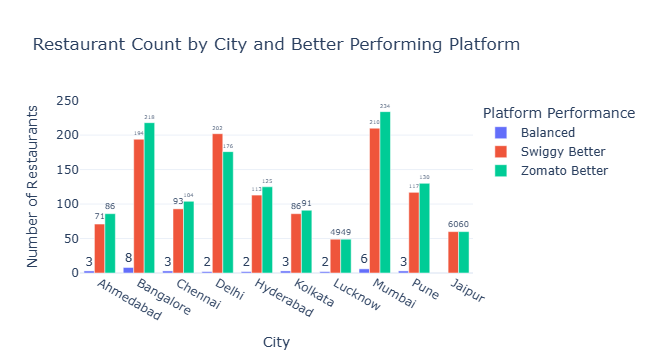

In [28]:
city_platform = (
    df.groupby(['city', 'platform_performance_better'])
      .size()
      .reset_index(name='Restaurant Count')
)
fig = px.bar(
    city_platform,
    x='city',
    y='Restaurant Count',
    color='platform_performance_better',
    barmode='group',
    text='Restaurant Count',
    title='Restaurant Count by City and Better Performing Platform',
    labels={
        'city': 'City',
        'Restaurant Count': 'Number of Restaurants',
        'platform_performance_better': 'Better Platform'
    }
)

fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title='City',
    yaxis_title='Number of Restaurants',
    legend_title='Platform Performance',
    template='plotly_white'
)

fig.show()

In [ ]:
#scatterchart

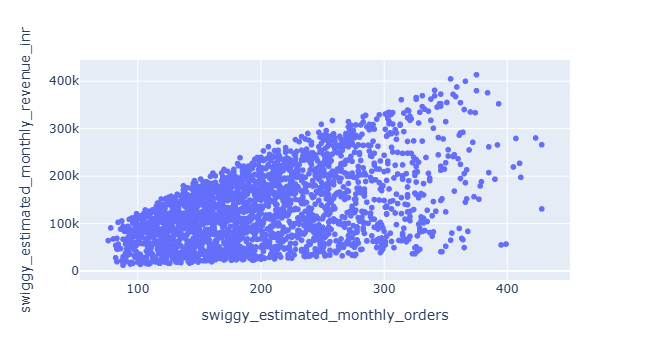

In [29]:
fig2=px.scatter(df,
                x="swiggy_estimated_monthly_orders",
                y="swiggy_estimated_monthly_revenue_inr"
               )
fig2.show()

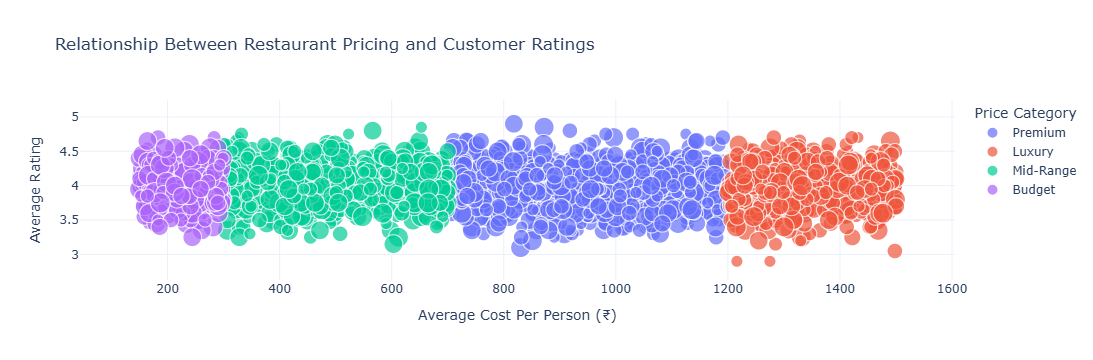

In [38]:
# Create scatter plot
fig = px.scatter(
    df,
    x='avg_cost_per_person_inr',
    y='average_rating_both_platforms',
    color='price_category',
    size='amenities_count',
    title='Relationship Between Restaurant Pricing and Customer Ratings',
    labels={
        'avg_cost_per_person_inr': 'Average Cost Per Person (₹)',
        'average_rating_both_platforms': 'Average Rating',
        'price_category': 'Price Category',
        'amenities_count': 'Amenities Count'
    }
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Average Cost Per Person (₹)',
    yaxis_title='Average Rating',
    legend_title='Price Category'
)

fig.show()

In [ ]:
#pie chart

In [ ]:
fig3=px.pie(df,
           names="restaurant_type",
           values="zomato_rating")
fig3.show()

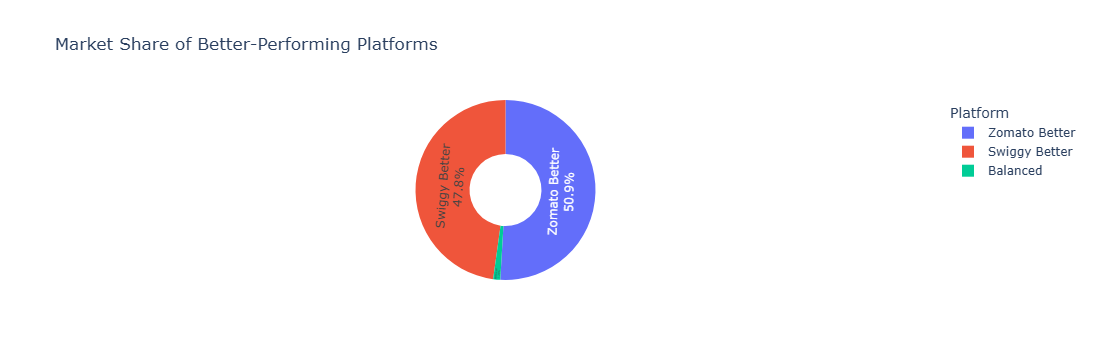

In [31]:
# Group the data
platform_share = (
    df.groupby('platform_performance_better')
      .size()
      .reset_index(name='Restaurant Count')
)

# Create pie chart
fig = px.pie(
    platform_share,
    names='platform_performance_better',
    values='Restaurant Count',
    title='Market Share of Better-Performing Platforms',
    hole=0.4  # Remove this line if you want a normal pie chart
)

# Show percentage and label
fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.update_layout(
    template='plotly_white',
    legend_title='Platform'
)

fig.show()

In [ ]:
#bublechart

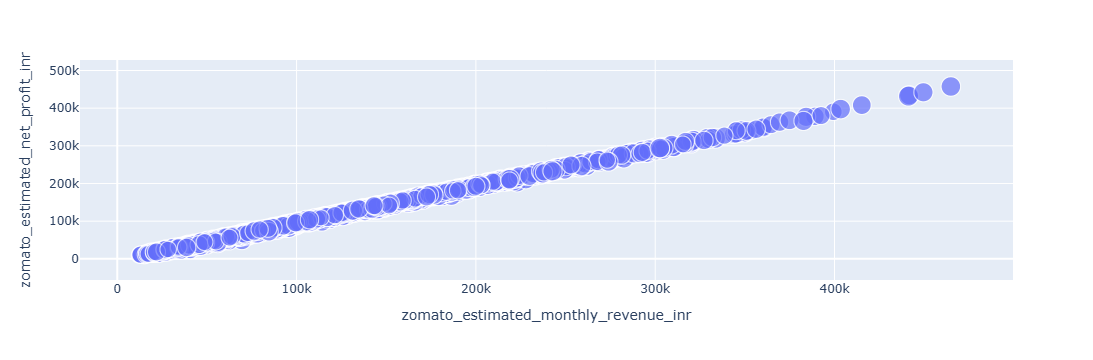

In [54]:
fig4=px.scatter(
    df,
    x="zomato_estimated_monthly_revenue_inr",
    y="zomato_estimated_net_profit_inr",
    size="zomato_rating"
)
fig4.show()

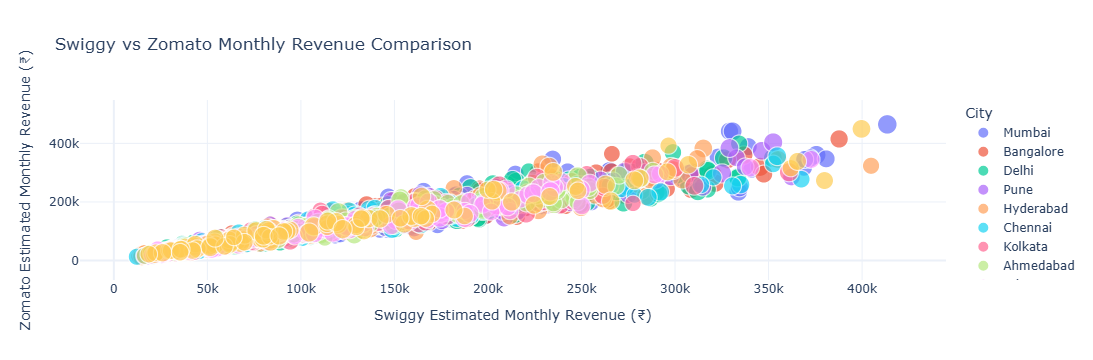

In [56]:
import plotly.express as px

# Create Bubble Chart
fig = px.scatter(
    df,
    x='swiggy_estimated_monthly_revenue_inr',
    y='zomato_estimated_monthly_revenue_inr',
    size='average_rating_both_platforms',
    color='city',
    hover_name='restaurant_type',
    hover_data={
        'restaurant_type': True,
        'price_category': True,
        'average_rating_both_platforms': ':.2f',
        'swiggy_estimated_monthly_revenue_inr': ':,.0f',
        'zomato_estimated_monthly_revenue_inr': ':,.0f'
    },
    title='Swiggy vs Zomato Monthly Revenue Comparison',
    labels={
        'swiggy_estimated_monthly_revenue_inr': 'Swiggy Monthly Revenue (₹)',
        'zomato_estimated_monthly_revenue_inr': 'Zomato Monthly Revenue (₹)',
        'average_rating_both_platforms': 'Average Rating',
        'city': 'City'
    }
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Swiggy Estimated Monthly Revenue (₹)',
    yaxis_title='Zomato Estimated Monthly Revenue (₹)',
    legend_title='City'
)

fig.show()

In [ ]:
#boxplot

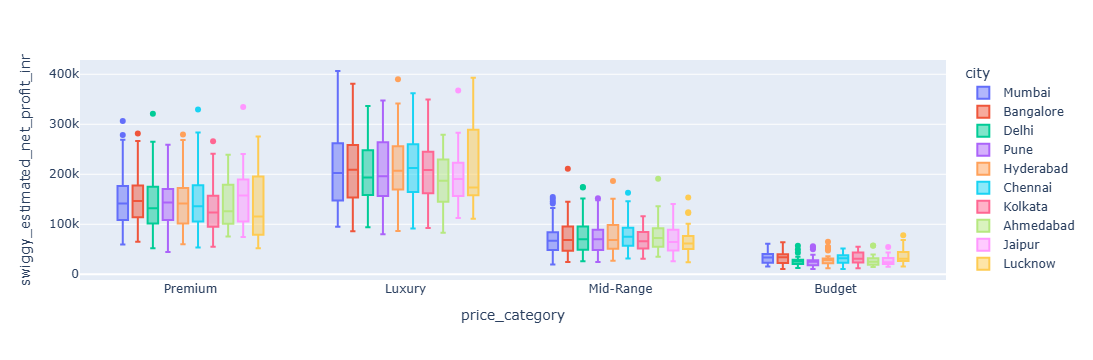

In [43]:
fig5=px.box(df,
           x="price_category",
            y="swiggy_estimated_net_profit_inr",
           color="city")
fig5.show()

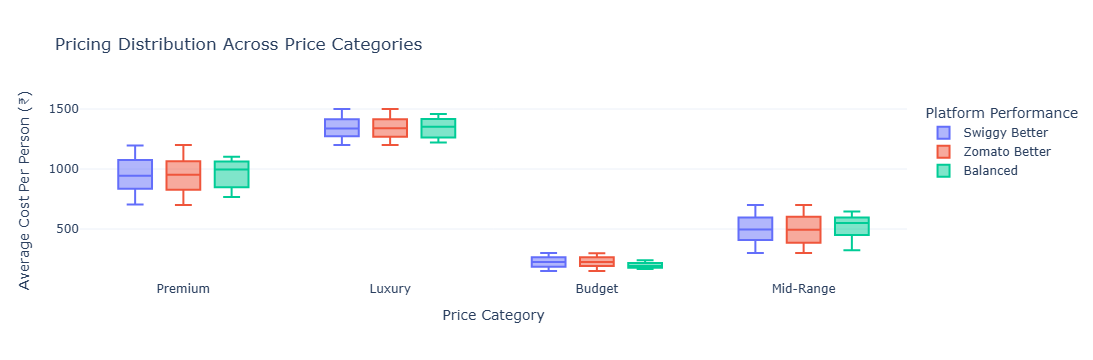

In [42]:
# Create box plot
fig = px.box(
    df,
    x='price_category',
    y='avg_cost_per_person_inr',
    color='platform_performance_better',
    points='outliers',  # Show only outlier points
    title='Pricing Distribution Across Price Categories',
    labels={
        'price_category': 'Price Category',
        'avg_cost_per_person_inr': 'Average Cost Per Person (₹)',
        'platform_performance_better': 'Better Performing Platform'
    }
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Price Category',
    yaxis_title='Average Cost Per Person (₹)',
    legend_title='Platform Performance'
)

fig.show()

In [ ]:
#violin chart

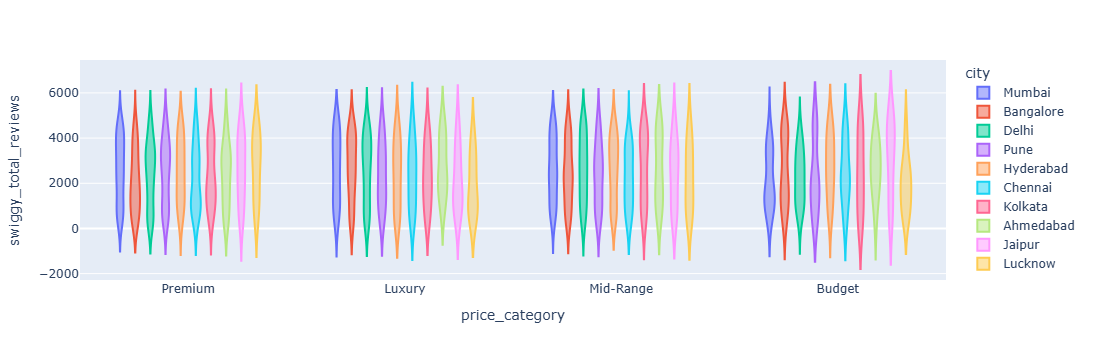

In [45]:
fig6=px.violin(df,
               x="price_category",
               y="swiggy_total_reviews",
               color="city"
              )
fig6.show()
               

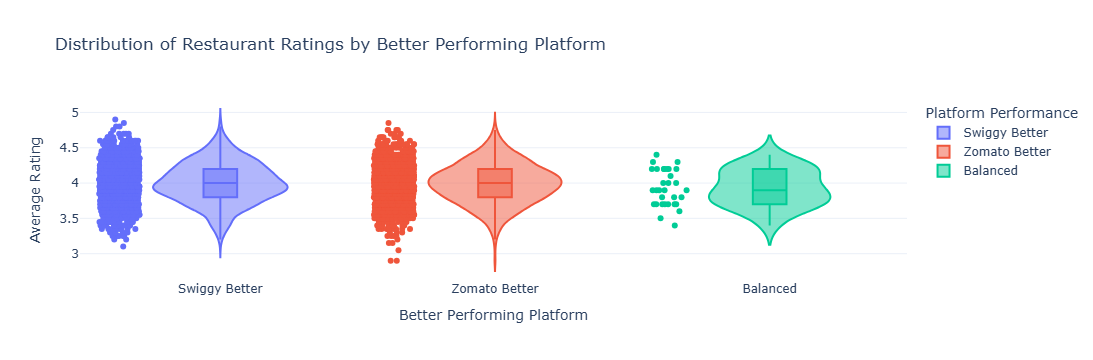

In [44]:
# Create violin plot
fig = px.violin(
    df,
    x='platform_performance_better',
    y='average_rating_both_platforms',
    color='platform_performance_better',
    box=True,           # Show box plot inside the violin
    points='all',       # Display all observations
    title='Distribution of Restaurant Ratings by Better Performing Platform',
    labels={
        'platform_performance_better': 'Better Performing Platform',
        'average_rating_both_platforms': 'Average Rating'
    }
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Better Performing Platform',
    yaxis_title='Average Rating',
    legend_title='Platform Performance'
)

fig.show()

In [ ]:
#line chart

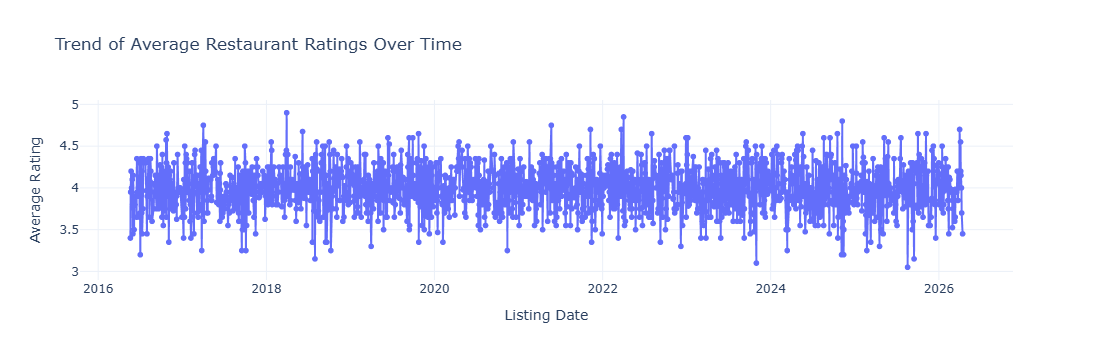

In [33]:
# Convert listing_date to datetime (if not already)
df['listing_date'] = pd.to_datetime(df['listing_date'])

# Group the data
rating_trend = (
    df.groupby('listing_date')['average_rating_both_platforms']
      .mean()
      .reset_index()
)

# Create line chart
fig = px.line(
    rating_trend,
    x='listing_date',
    y='average_rating_both_platforms',
    markers=True,
    title='Trend of Average Restaurant Ratings Over Time',
    labels={
        'listing_date': 'Listing Date',
        'average_rating_both_platforms': 'Average Rating'
    }
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Listing Date',
    yaxis_title='Average Rating'
)

fig.show()

In [34]:
df1=df.groupby(["restaurant_type","price_category"])["zomato_rating"].mean().reset_index()

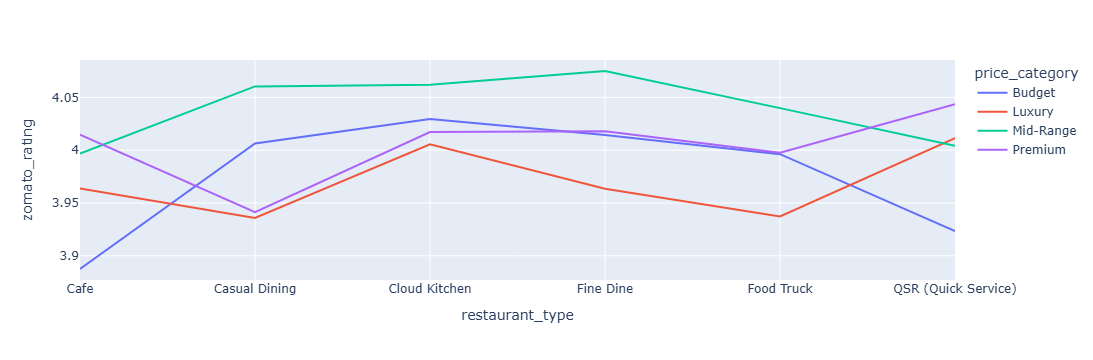

In [35]:
fig8=px.line(df1,
            x="restaurant_type",
            y="zomato_rating",
            color="price_category"
)
fig8.show()

In [ ]:
#areachart

In [ ]:
fig9=px.area(df1,
            x="restaurant_type",
            y="zomato_rating",
            color="price_category"
)
fig9.show()

In [ ]:
#scatter_3d

In [ ]:
fig10=px.scatter_3d(df,
                   x="swiggy_estimated_monthly_orders",
                y="swiggy_estimated_monthly_revenue_inr"
               )
fig10.show() 

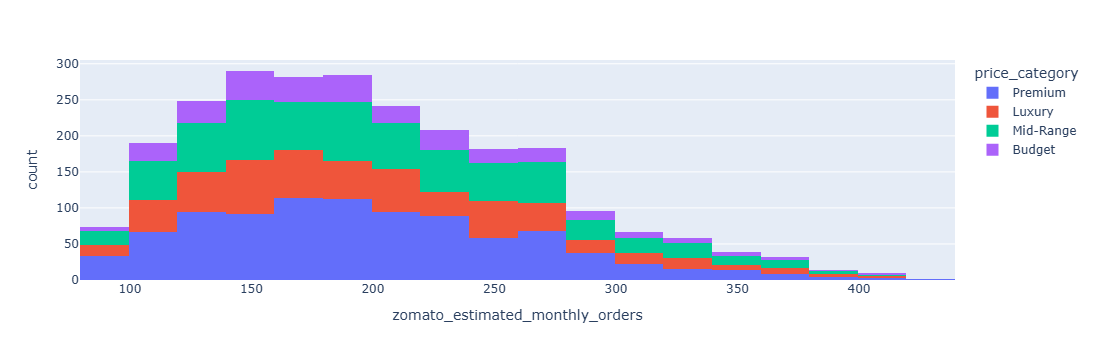

In [41]:
fig11=px.histogram(
    df,
    x="zomato_estimated_monthly_orders",
color="price_category",
nbins=20)
fig11.show()

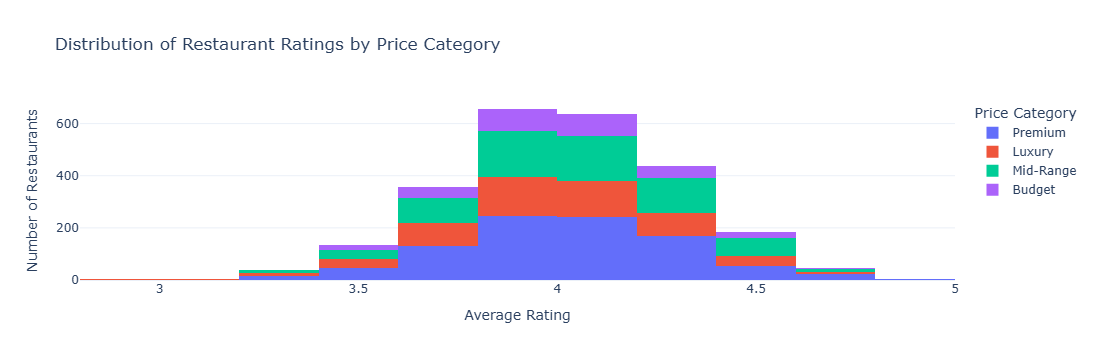

In [39]:
# Create histogram
fig = px.histogram(
    df,
    x='average_rating_both_platforms',
    color='price_category',
    nbins=20,  # Adjust the number of bins if needed
    title='Distribution of Restaurant Ratings by Price Category',
    labels={
        'average_rating_both_platforms': 'Average Rating',
        'price_category': 'Price Category'
    }
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Average Rating',
    yaxis_title='Number of Restaurants',
    legend_title='Price Category'
)

fig.show()

In [ ]:
#density heatmap

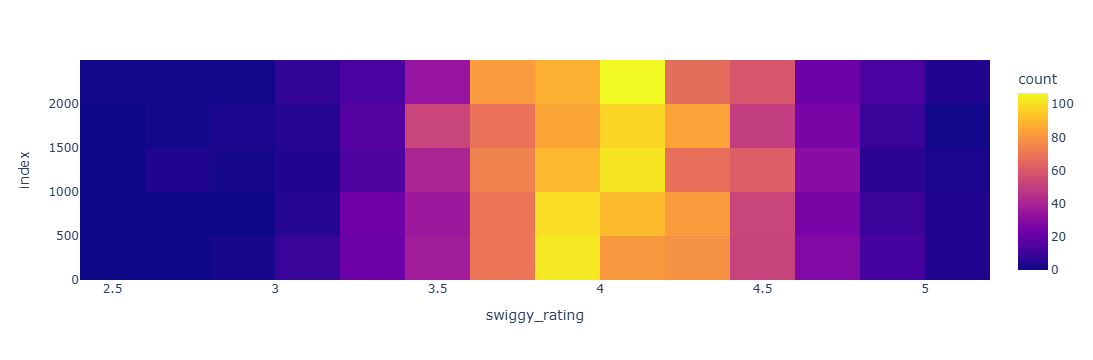

In [57]:
fig12=px.density_heatmap(df,
                         x="swiggy_rating",
                        )
fig12.show()

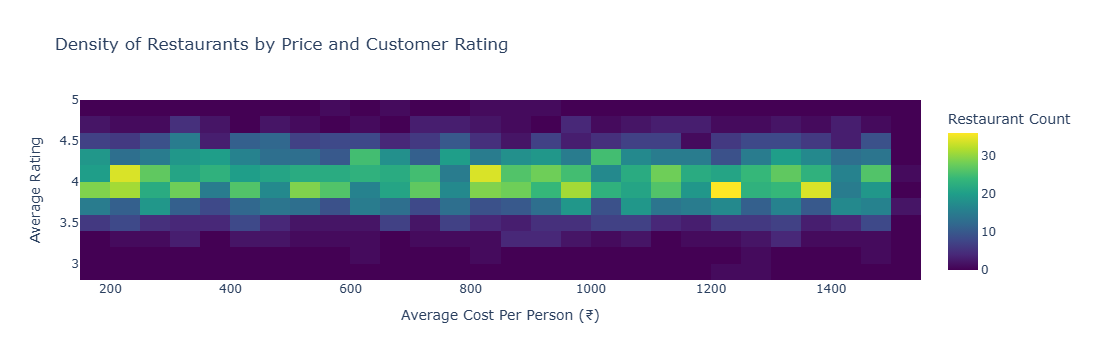

In [58]:
import plotly.express as px

# Create Density Heatmap
fig = px.density_heatmap(
    df,
    x='avg_cost_per_person_inr',
    y='average_rating_both_platforms',
    nbinsx=30,
    nbinsy=20,
    color_continuous_scale='Viridis',
    title='Density of Restaurants by Price and Customer Rating',
    labels={
        'avg_cost_per_person_inr': 'Average Cost Per Person (₹)',
        'average_rating_both_platforms': 'Average Rating'
    }
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Average Cost Per Person (₹)',
    yaxis_title='Average Rating',
    coloraxis_colorbar_title='Restaurant Count'
)

fig.show()

In [ ]:
#tree map chart

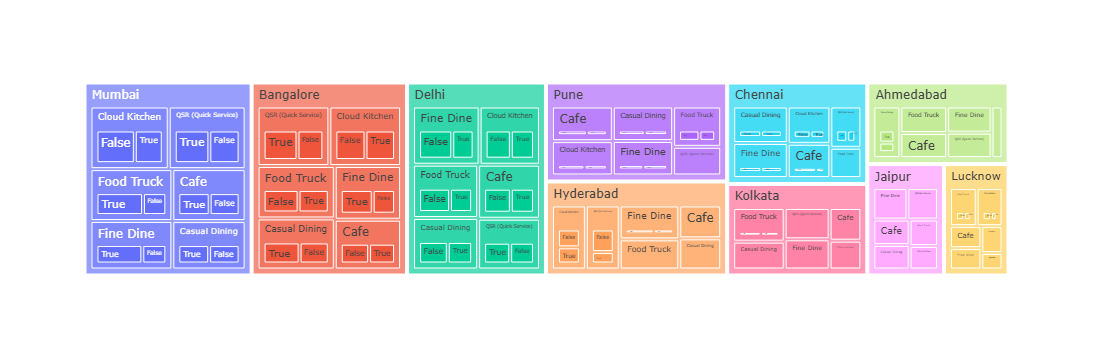

In [51]:
fig13=px.treemap(
    df,
    path=["city","restaurant_type","has_own_website"],
    values="zomato_rating")
fig13.show()

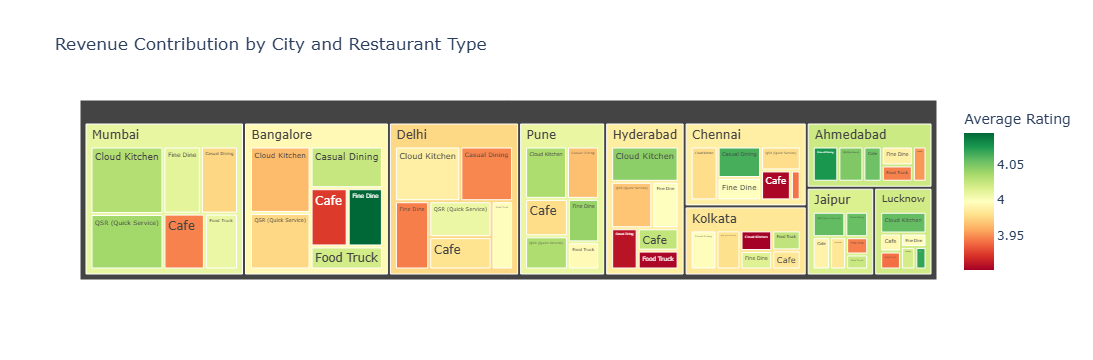

In [47]:
# Group the data
treemap_data = (
    df.groupby(['city', 'restaurant_type'])
      .agg({
          'swiggy_estimated_monthly_revenue_inr': 'sum',
          'average_rating_both_platforms': 'mean'
      })
      .reset_index()
)

# Create treemap
fig = px.treemap(
    treemap_data,
    path=['city', 'restaurant_type'],
    values='swiggy_estimated_monthly_revenue_inr',
    color='average_rating_both_platforms',
    color_continuous_scale='RdYlGn',
    title='Revenue Contribution by City and Restaurant Type',
    labels={
        'swiggy_estimated_monthly_revenue_inr': 'Monthly Revenue (₹)',
        'average_rating_both_platforms': 'Average Rating'
    }
)

fig.update_layout(
    template='plotly_white'
)

fig.show()

In [ ]:
#sunburst chart

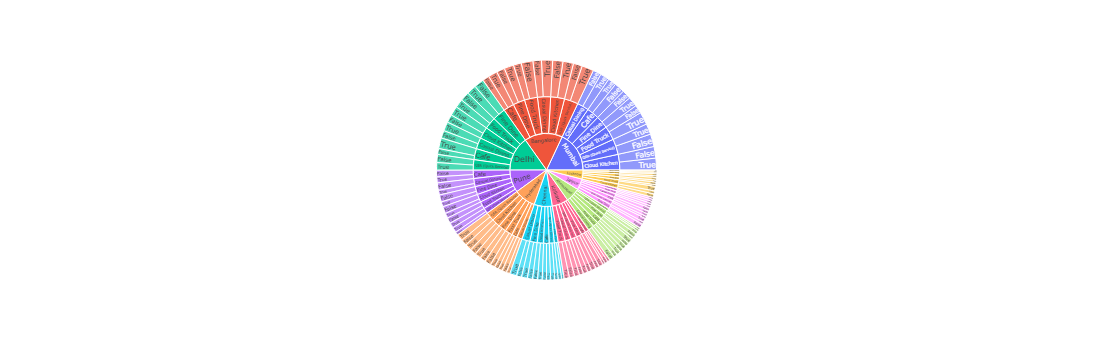

In [52]:
fig14=px.sunburst(df,
                  path=["city","restaurant_type","has_own_app"],
                  values="swiggy_rating")
fig14.show()

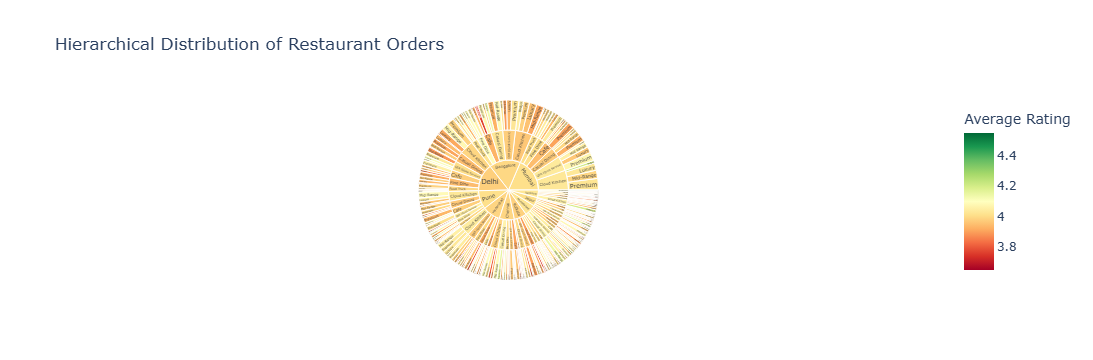

In [53]:
import pandas as pd
import plotly.express as px

# Group the data
sunburst_data = (
    df.groupby(['city', 'restaurant_type', 'price_category'])
      .agg({
          'zomato_estimated_monthly_orders': 'sum',
          'average_rating_both_platforms': 'mean'
      })
      .reset_index()
)

# Create Sunburst Chart
fig = px.sunburst(
    sunburst_data,
    path=['city', 'restaurant_type', 'price_category'],
    values='zomato_estimated_monthly_orders',
    color='average_rating_both_platforms',
    color_continuous_scale='RdYlGn',
    title='Hierarchical Distribution of Restaurant Orders',
    labels={
        'zomato_estimated_monthly_orders': 'Monthly Orders',
        'average_rating_both_platforms': 'Average Rating'
    }
)

fig.update_layout(
    template='plotly_white'
)

fig.show()

In [ ]:
#funnel chart

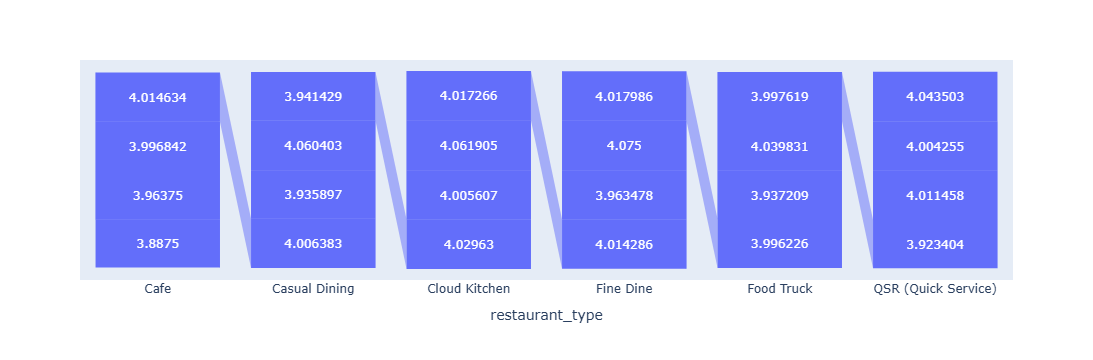

In [46]:
fig15=px.funnel(df1,
            x="restaurant_type",
            y="zomato_rating"            
)
fig15.show()

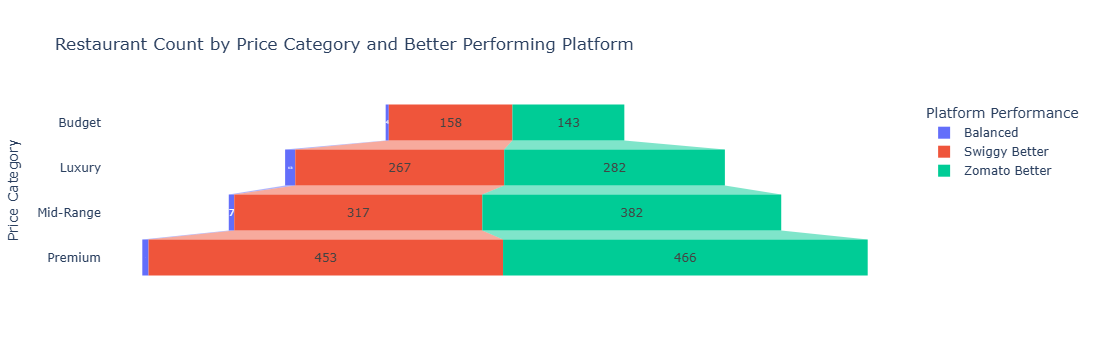

In [59]:
import pandas as pd
import plotly.express as px

# Group the data
funnel_data = (
    df.groupby(['price_category', 'platform_performance_better'])
      .size()
      .reset_index(name='Restaurant Count')
)

# Create Funnel Chart
fig = px.funnel(
    funnel_data,
    y='price_category',
    x='Restaurant Count',
    color='platform_performance_better',
    title='Restaurant Count by Price Category and Better Performing Platform',
    labels={
        'price_category': 'Price Category',
        'Restaurant Count': 'Number of Restaurants',
        'platform_performance_better': 'Better Performing Platform'
    }
)

fig.update_layout(
    template='plotly_white',
    legend_title='Platform Performance'
)

fig.show()